In [16]:
# Load Data
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("team_data.csv")

In [17]:
# Simulate Coach Data
np.random.seed(42)
df['experience'] = np.random.randint(1, 20, size=len(df))
df['wins'] = np.random.randint(10, 100, size=len(df))

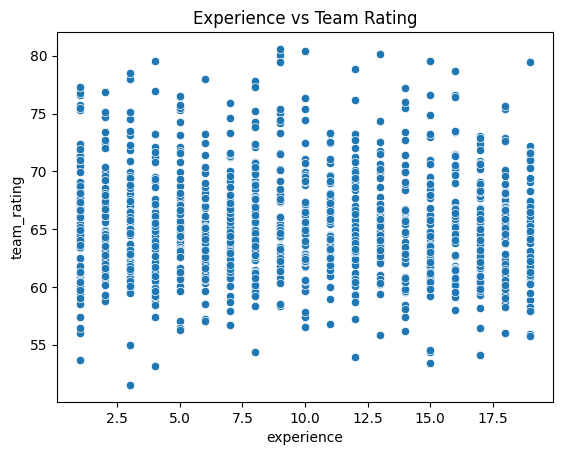

In [18]:
# EDA
plt.figure()
sns.scatterplot(x=df['experience'], y=df['team_rating'])
plt.title("Experience vs Team Rating")
plt.show()

In [19]:
# Target
df['coach_impact'] = df['team_rating']*0.7 + df['wins']*0.3

In [44]:
# Model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
X = df[['experience','wins','team_rating']]
y = df['coach_impact']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [45]:
# Evaluation
pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, pred))
print("Coach RMSE:", rmse)

Coach RMSE: 0.5562498612528168


In [46]:
# Save Models
import joblib
joblib.dump(model, "coach_model.pkl")

['coach_model.pkl']